# CREDIT SCORING MODEL - "GIVE ME SOME CREDIT"
This credit scoring model uses a Random Forest algorithm to assess loan default risk. By applying cost-sensitive learning to handle class imbalance, it effectively identifies high-risk borrowers with 80% recall. This allows financial institutions to minimize default losses while maintaining a stable, automated credit approval process.

# STEP 1: UPLOAD & LOAD THE DATASET

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

#uploaded 'cs-training.csv' downloaded from Kaggle:"

# Read the file (Kaggle dataset uses the first column as an unnamed index)
df = pd.read_csv('cs-training.csv', index_col=0)

print("\n--- Dataset Loaded Successfully ---")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")


--- Dataset Loaded Successfully ---
Shape: 150000 rows, 11 columns



# STEP 1.5: VISUALIZE & UNDERSTAND THE DATASET (EDA)

--- STEP 1.5: Visualizing the Raw Data ---


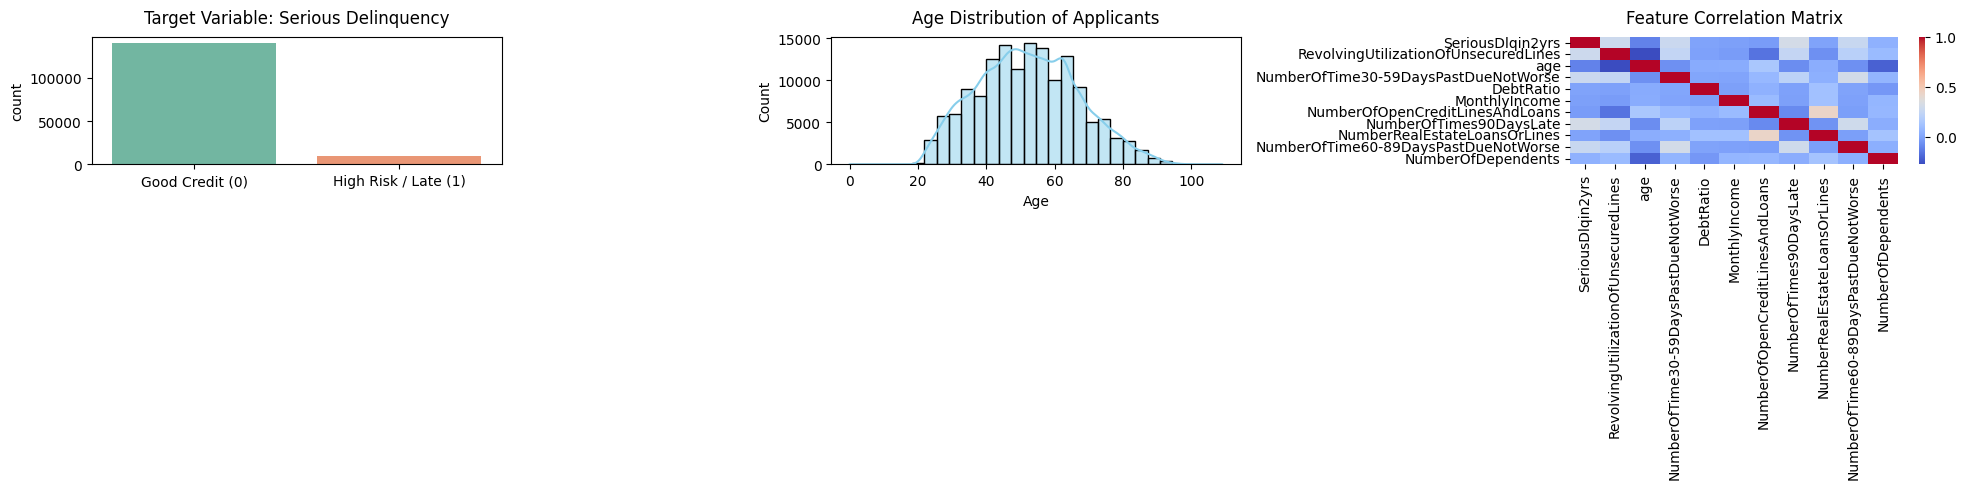


--- Summary Statistics for Key Features ---
             age  RevolvingUtilizationOfUnsecuredLines  MonthlyIncome
count  150000.00                             150000.00      150000.00
mean       52.30                                  0.32        6418.45
std        14.77                                  0.36       12890.40
min         0.00                                  0.00           0.00
25%        41.00                                  0.03        3903.00
50%        52.00                                  0.15        5400.00
75%        63.00                                  0.56        7400.00
max       109.00                                  2.00     3008750.00


In [13]:
print("--- STEP 1.5: Visualizing the Raw Data ---")

# Setup a large plotting area with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Target Variable Distribution (Class Imbalance)
# FIX 1: Assigned 'hue' and set 'legend=False' to satisfy newer Seaborn requirements
sns.countplot(x='SeriousDlqin2yrs', data=df, ax=axes[0], hue='SeriousDlqin2yrs', palette='Set2', legend=False)
axes[0].set_title('Target Variable: Serious Delinquency', fontsize=12, pad=10)

# FIX 2: Explicitly set the tick locations BEFORE mapping text labels to satisfy Matplotlib's FixedLocator rule
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Good Credit (0)', 'High Risk / Late (1)'])
axes[0].set_xlabel('')

# 2. Distribution of Applicant Age
sns.histplot(df['age'], bins=30, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Age Distribution of Applicants', fontsize=12, pad=10)
axes[1].set_xlabel('Age')

# 3. Correlation Heatmap
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', ax=axes[2], cbar=True)
axes[2].set_title('Feature Correlation Matrix', fontsize=12, pad=10)

plt.tight_layout()
plt.show()

# 4. Quick Descriptive Statistics for key features
print("\n--- Summary Statistics for Key Features ---")
print(df[['age', 'RevolvingUtilizationOfUnsecuredLines', 'MonthlyIncome']].describe().round(2))

# STEP 2: DATA CLEANING & PREPROCESSING

In [7]:
print("--- STEP 2: Cleaning Data & Handling Outliers ---")

# 1. Fill missing MonthlyIncome with the median (Explicit assignment avoids warnings)
median_income = df['MonthlyIncome'].median()
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(median_income)

# 2. Fill missing NumberOfDependents with the mode
mode_dependents = df['NumberOfDependents'].mode()[0]
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(mode_dependents)

# 3. Cap extreme outliers in RevolvingUtilizationOfUnsecuredLines
# Realistically, utilization is a ratio between 0 and 1. We cap any values above 2.0 to 1.0.
df['RevolvingUtilizationOfUnsecuredLines'] = np.where(
    df['RevolvingUtilizationOfUnsecuredLines'] > 2.0,
    1.0,
    df['RevolvingUtilizationOfUnsecuredLines']
)

# 4. Handle anomalous values in delinquency counts (replacing codes like 96 or 98)
for col in ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']:
    col_median = df[col].median()
    df[col] = np.where(df[col] > 20, col_median, df[col])

print("Missing values successfully filled. Outliers capped safely without any warnings!")

--- STEP 2: Cleaning Data & Handling Outliers ---
Missing values successfully filled. Outliers capped safely without any warnings!


# STEP 3: PREPARE DATA FOR THE ALGORITHM

In [8]:
print("--- Splitting the Data ---")

# Define our Features (X) and our Target (y)
X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

# Split: 80% of data for training, 20% for testing
# stratify=y ensures we keep that 93% / 7% class imbalance in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}\n")

--- Splitting the Data ---
Training data shape: (120000, 10)
Testing data shape: (30000, 10)



# STEP 4: Training

In [9]:
print("--- Training the Random Forest Algorithm ---")

# Initialize the Algorithm
# class_weight='balanced' tells the algorithm to pay extra attention to the minority class (the risky borrowers)
algo = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)

# The algorithm learns here.
algo.fit(X_train, y_train)

# Now that it has learned, we force it to take the final exam (predicting on X_test)
y_pred_classes = algo.predict(X_test)         # Predicts hard 0s and 1s
y_pred_probabilities = algo.predict_proba(X_test)[:, 1] # Predicts the % probability of being high risk

print("Algorithm training complete! Now let's grade it.")

--- Training the Random Forest Algorithm ---
Algorithm training complete! Now let's grade it.


# STEP 5: PERFORMANCE EVALUATION (Applying Visual & Text Metrics)

--- STEP 5: Performance Evaluation Metrics ---
1. Classification Report:
                 precision    recall  f1-score   support

Good Credit (0)       0.98      0.77      0.86     27995
  High Risk (1)       0.20      0.80      0.32      2005

       accuracy                           0.77     30000
      macro avg       0.59      0.79      0.59     30000
   weighted avg       0.93      0.77      0.83     30000


2. Generating Confusion Matrix Heatmap...


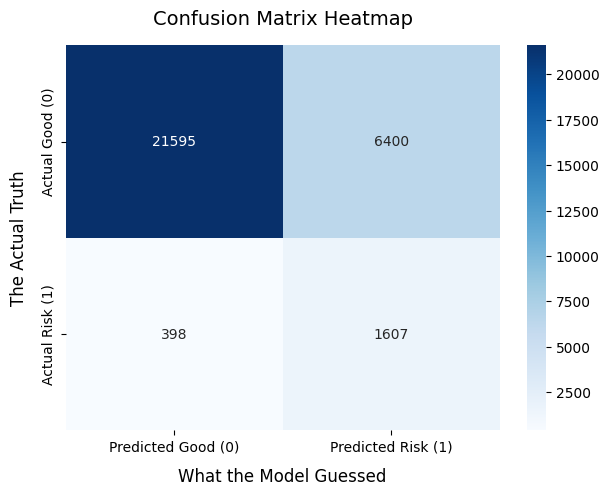


3. ROC-AUC Score: 0.8608
Generating ROC Curve Plot...


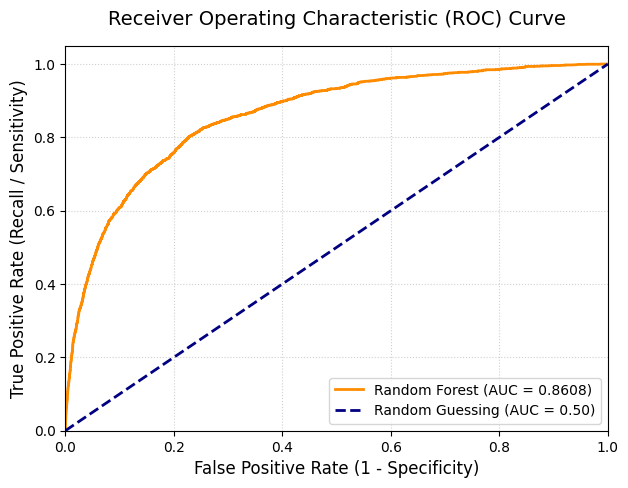

In [11]:
print("--- STEP 5: Performance Evaluation Metrics ---")

# 1. Classification Report (Precision, Recall, F1)
print("1. Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=['Good Credit (0)', 'High Risk (1)']))

# 2. Compute the Confusion Matrix numbers
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# 3. Graphical Confusion Matrix using Seaborn
print("\n2. Generating Confusion Matrix Heatmap...")
plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Good (0)', 'Predicted Risk (1)'],
    yticklabels=['Actual Good (0)', 'Actual Risk (1)']
)
plt.title('Confusion Matrix Heatmap', fontsize=14, pad=15)
plt.xlabel('What the Model Guessed', fontsize=12, labelpad=10)
plt.ylabel('The Actual Truth', fontsize=12, labelpad=10)
plt.show()

# 4. Compute ROC-AUC score and curve coordinates
roc_auc = roc_auc_score(y_test, y_pred_probabilities)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probabilities)

print(f"\n3. ROC-AUC Score: {roc_auc:.4f}")

# 5. Graphical ROC Curve using Matplotlib
print("Generating ROC Curve Plot...")
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Random Forest (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, pad=15)
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()